In [275]:
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.ndimage import uniform_filter1d
from minisom import MiniSom
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from sklearn.metrics import silhouette_score
import matplotlib.gridspec as gridspec
from collections import defaultdict
import cdsapi
from pathlib import Path

In [276]:
missing_dates = [
    '200204250000', '200208300000', '200304150000', '200304160000',
    '200306250000', '200307270000', '200307280000', '200312280000',
    '200404140000', '200408090000', '200905280000', '201105210000',
    '202005240000', '200510240000'
]
missing_dt = pd.to_datetime(missing_dates, format='%Y%m%d%H%M')
# selection of desired days
pph = xr.open_dataset('data/raw_data/labelled_pph.nc')
pph_time = pd.to_datetime(pph['time'].values, format='%Y%m%d%H%M')

cats = ['SLGT', 'ENH', 'MDT', 'HIGH']
mask = np.isin(pph['MAX_CAT'].values, cats) & (pph_time> '2002-04-01') & (pph_time < '2020-01-01') & ~np.isin(pph_time, missing_dt)

times = pph_time[mask]
times_shifted = times + np.timedelta64(1, 'D')

In [277]:
ds = xr.open_dataset('data/raw_data/clustering_fields.nc')
ds = ds.isel(y=slice(None, None, -1))
ds = ds.assign_coords(y=np.arange(ds.sizes['y']))

z500 = ds.Z.sel(channel="z500")
q850 = ds.Z.sel(channel="q850")
u850 = ds.Z.sel(channel="u850")
v850 = ds.Z.sel(channel="v850")
u500 = ds.Z.sel(channel="u500")
v500 = ds.Z.sel(channel="v500")

z500_dm = z500 - z500.mean(dim=("y", "x"))
z500_dm.name = "z500_dm"

In [278]:
R = 6_371_000
ddeg = 0.25
dy = np.deg2rad(ddeg) * R
dx = dy

In [279]:
dvdx_500 = v500.differentiate("x") / dx
dudy_500 = u500.differentiate("y") / dy

vort500 = dvdx_500 - dudy_500
vort500.name = "vort500"

In [280]:
#d2zdx2 = z500.differentiate("x").differentiate("x") / (dx**2)
#d2zdy2 = z500.differentiate("y").differentiate("y") / (dy**2)

#lap_z500 = d2zdx2 + d2zdy2
#lap_z500.name = "lap_z500"

In [281]:
qflux_u850 = q850 * u850
qflux_v850 = q850 * v850

qflux_u850.name = "qflux_u850"
qflux_v850.name = "qflux_v850"

In [282]:
feature_ds = xr.Dataset(
    {
        "z500_dm": z500_dm,
        "vort500": vort500,
        #"lap_z500": lap_z500,
        "qflux_u850": qflux_u850,
        "qflux_v850": qflux_v850,
    }
)

In [283]:
full_heights = xr.open_dataset('data/raw_data/heights.nc')

z = full_heights['z'].load()/9.81 /10  # (time, lat, lon)

z = z.squeeze('pressure_level')

# day-of-year climatology
climo = z.groupby('valid_time.dayofyear').mean('valid_time')

# smooth climatology (cyclic!)
climo_vals = climo.values  # (dayofyear, lat, lon)

climo_smooth = uniform_filter1d(
    climo_vals,
    size=15,
    axis=0,
    mode='wrap'
)

climo = xr.DataArray(
    climo_smooth,
    dims=climo.dims,
    coords=climo.coords
)

# anomalies
doy = z['valid_time'].dt.dayofyear
anom = z - climo.sel(dayofyear=doy)

# detrending to remove climate signal
p = anom.polyfit(dim='valid_time', deg=1)
trend = xr.polyval(anom['valid_time'], p.polyfit_coefficients)

anom_dt = anom - trend

missing_dates = [
    '200204250000', '200208300000', '200304150000', '200304160000',
    '200306250000', '200307270000', '200307280000', '200312280000',
    '200404140000', '200408090000', '200905280000', '201105210000',
    '202005240000', '200510240000'
]
missing_dt = pd.to_datetime(missing_dates, format='%Y%m%d%H%M')

# selection of desired days
pph = xr.open_dataset('data/raw_data/labelled_pph.nc')
pph_time = pd.to_datetime(pph['time'].values, format='%Y%m%d%H%M')

cats = ['SLGT', 'ENH', 'MDT', 'HIGH']
mask = np.isin(pph['MAX_CAT'].values, cats) & (pph_time> '2002-04-01') & (pph_time < '2020-01-01') & ~np.isin(pph_time, missing_dt)

times_shifted = pph_time[mask] + np.timedelta64(1, 'D')

anom_dt = anom_dt.sel(valid_time=times_shifted)
anom = anom.sel(valid_time=times_shifted)

# latitude weight and prep
weights = np.sqrt(np.cos(np.deg2rad(anom_dt['latitude'])))
anom_w = anom_dt * weights

all_heights = anom_w.stack(space=('latitude','longitude')).transpose('valid_time','space')

Combine for PCA

In [284]:
storm_blocks = []

for v in feature_ds.data_vars:
    A = feature_ds[v].values  # (day, y, x)

    mu = A.mean()
    sigma = A.std()

    A_std = (A - mu) / sigma
    storm_blocks.append(A_std.reshape(len(feature_ds['day']), -1))
storm_matrix = np.concatenate(storm_blocks, axis=1)\

H = all_heights.values  # (day, space)

mu_h = H.mean()
sigma_h = H.std()

H_std = (H - mu_h) / sigma_h

X = np.concatenate([storm_matrix, H_std], axis=1)

In [308]:
pca = PCA(n_components=30, random_state=42) # TODO try more
PCs = pca.fit_transform(X)

Visualizing PCs

In [309]:
Ny = 97
Nx = 97
storm_size = Ny * Nx

blocks = {
    "z500_dm": storm_size,
    "vort500": storm_size,
    #"lap_z500": storm_size,
    "qflux_u850": storm_size,
    "qflux_v850": storm_size,
    "conus_z500": all_heights.sizes["space"],
}
offsets = {}
start = 0
for k, n in blocks.items():
    offsets[k] = (start, start + n)
    start += n

In [310]:
scaled = pca.components_ * np.sqrt(pca.explained_variance_)[:, None]

def eof_maps(varname):
    i0, i1 = offsets[varname]
    block = scaled[:, i0:i1]

    if varname == "conus_z500":
        da = xr.DataArray(
            block,
            dims=("mode", "space"),
            coords={"space": all_heights.space},
        ).unstack("space")
    else:
        da = xr.DataArray(
            block.reshape(-1, Ny, Nx),
            dims=("mode", "y", "x"),
            coords={"y": np.arange(Ny), "x": np.arange(Nx)},
        )

    return da

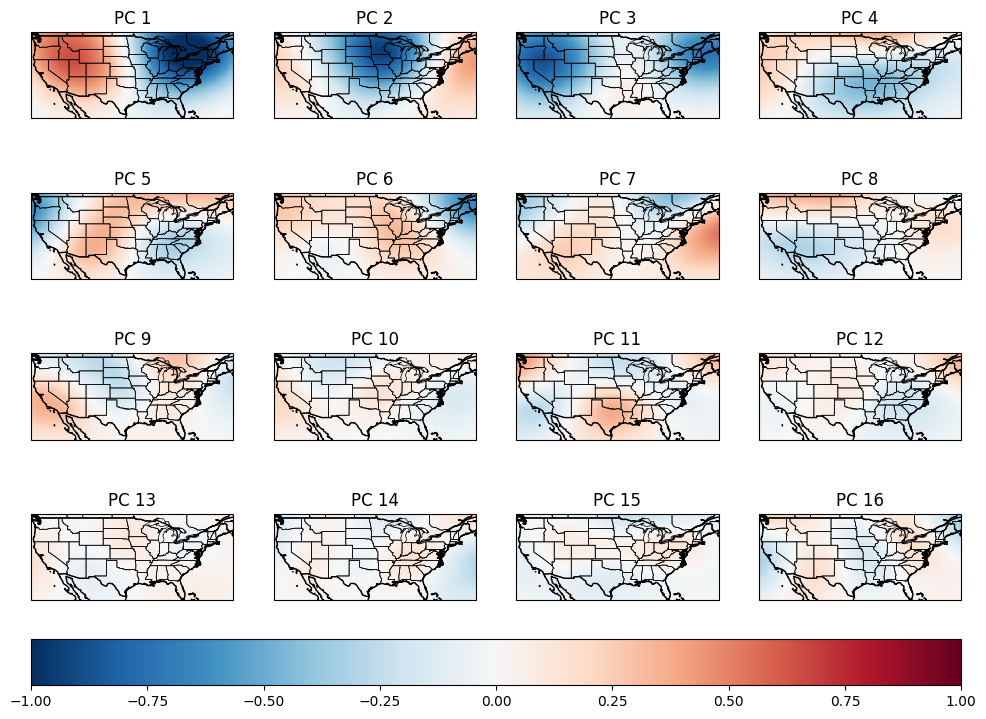

In [311]:
eofs_conus = eof_maps("conus_z500")

lats = anom_w.latitude
lons = anom_w.longitude
fig, axes = plt.subplots(
    4, 4,
    figsize=(12, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for i, ax in enumerate(axes.flat):
    eof = eofs_conus[i]

    im = ax.pcolormesh(
        lons, lats, eof,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin = -1,
        vmax = 1
    )

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=0.5)

    ax.set_title(f'PC {i+1}')

# colorbar (shared)
fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', pad=0.05)

plt.show()

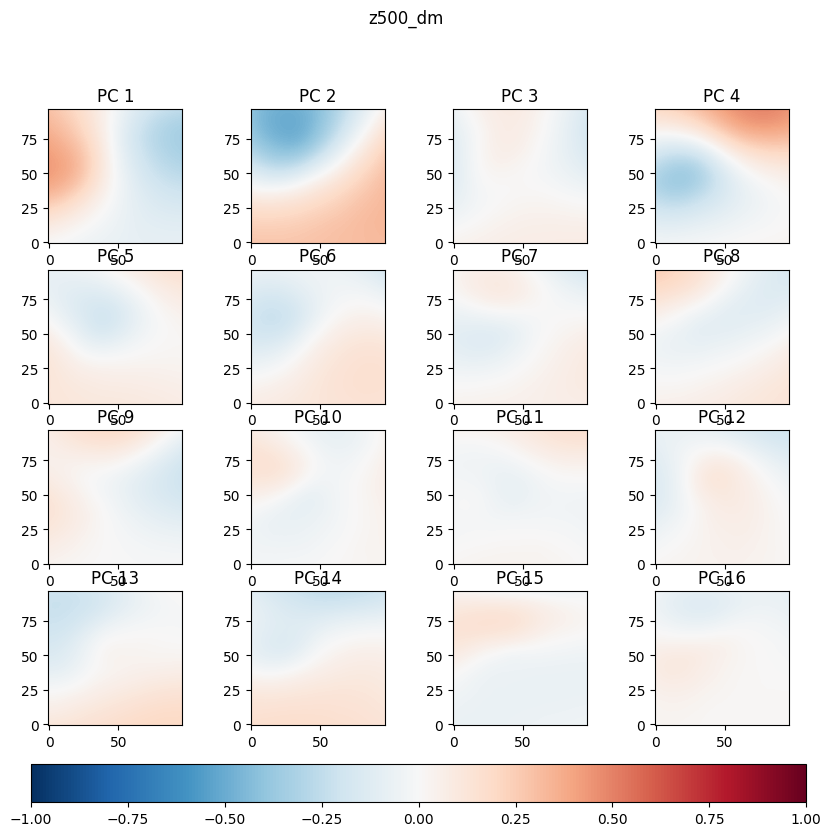

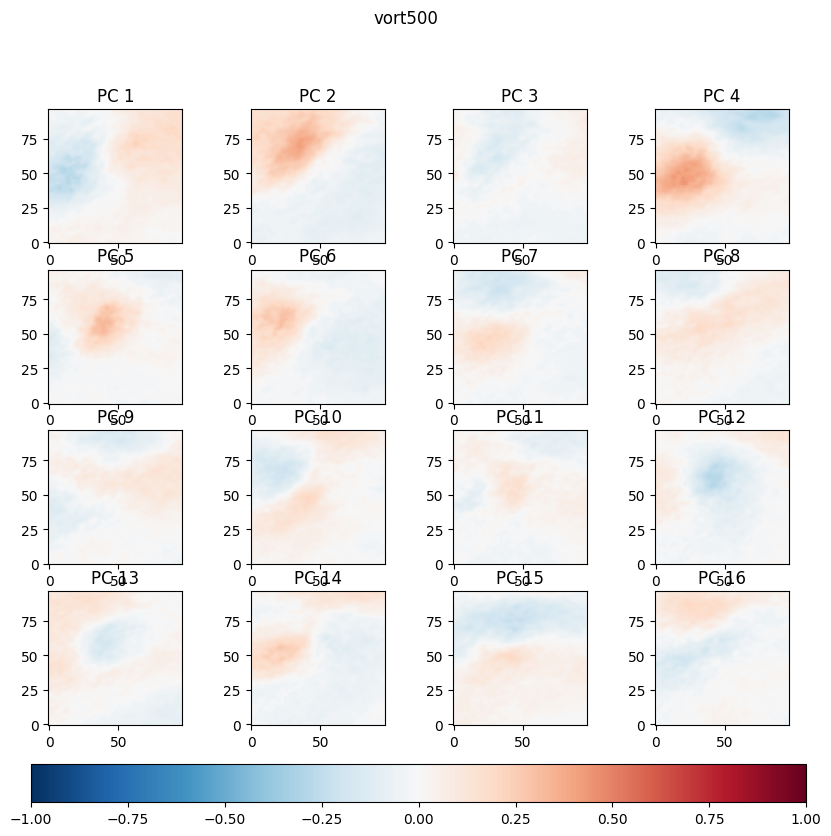

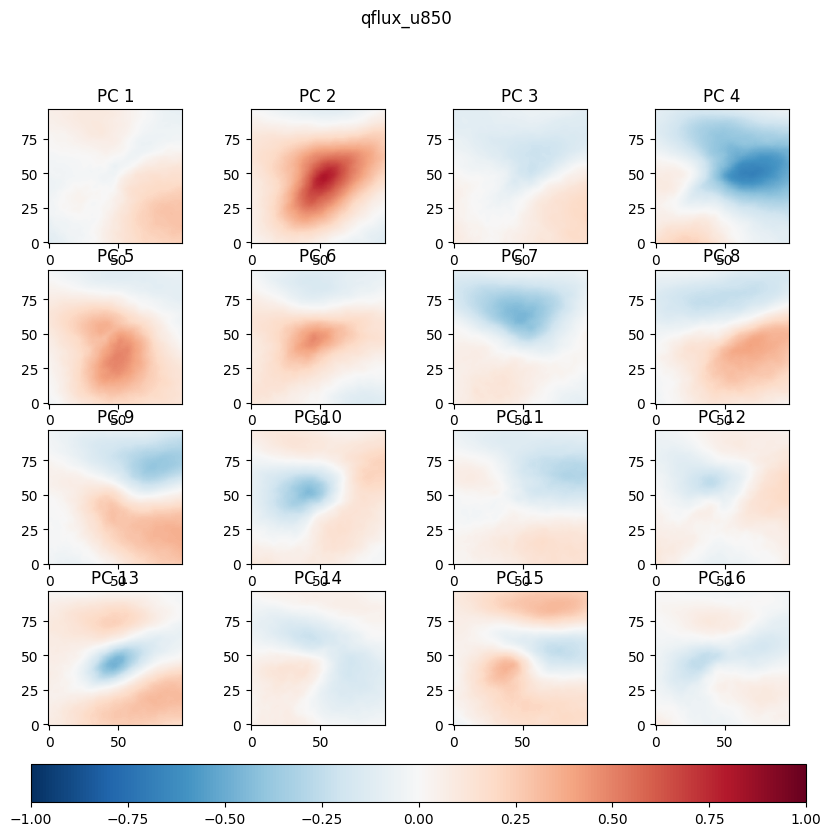

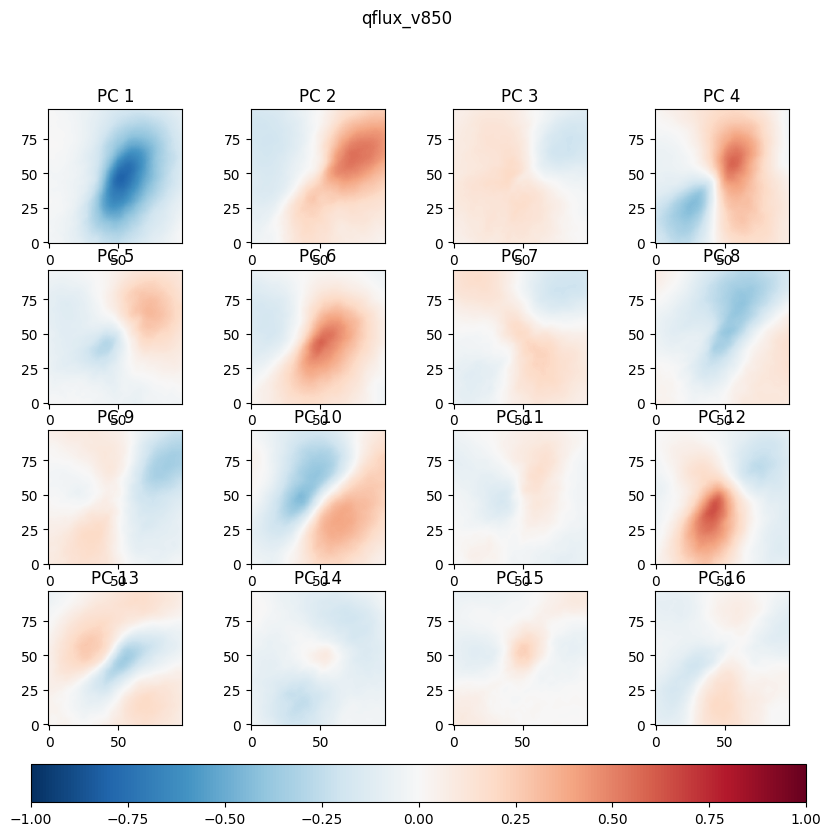

In [312]:
for v in blocks:
    if v != "conus_z500":
        eofs = eof_maps(v)
        # plot
        fig, axes = plt.subplots(4, 4, figsize=(10, 10))

        for i, ax in enumerate(axes.flat):
            im = ax.imshow(
                eofs[i],
                origin="lower",
                cmap="RdBu_r",
                vmin=-1,
                vmax=1,
            )
            ax.set_title(f"PC {i+1}")
        fig.suptitle(v)
        fig.colorbar(im, ax=axes.ravel().tolist(), orientation="horizontal", pad=0.05)
        plt.show()

Doing SOM

In [333]:
size_1 = 4
size_2 = 4
n_clusters = size_1 * size_2

som = MiniSom(size_1, size_2, PCs.shape[1],
              sigma=.5,
              learning_rate=.1,
              random_seed=42)

som.train(PCs, 200000)
def som_labels(som, X):
    winners = np.array([som.winner(x) for x in X])
    return winners[:,0] * som._weights.shape[1] + winners[:,1]

labels_cluster = som_labels(som, PCs)
score = silhouette_score(PCs, labels_cluster)
counts = np.bincount(labels_cluster)

print(score)
# tuned to highest score.. all vars and 20 pcs:
# for 3x3: sigma .1, learning rate .25, 200000 iterations -> .0677. Sigma .5 -> .0727
# for 4x4: sigma .1, learning rate .1, 200000 iterations -> .0617. Sigma .5 -> .0602

0.0557671406067295


In [334]:
def composite_multivar(labels, feature_ds, heights):
    comps = {}

    for k in np.unique(labels):
        idx = np.where(labels == k)[0]
        days = feature_ds.day.isel(day=idx)

        # storm-centered composites
        storm_comp = (
            feature_ds
            .sel(day=days)
            .mean("day")
        )

        # CONUS height composite
        conus_comp = (
            heights
            .sel(valid_time=days)
            .mean("day")
            .unstack("space")
        )

        comps[k] = dict(
            storm=storm_comp,
            conus=conus_comp
        )

    return comps

In [335]:
outlooks = xr.open_dataset('data/raw_data/grid_outlooks.nc')
reports = xr.open_dataset('data/raw_data/grid_reports.nc')
contingencies = xr.load_dataset('data/raw_data/binary_contingency_regions.nc')

In [336]:
labels_cluster = som_labels(som, PCs)
all_heights['valid_time'] = feature_ds.day.values

cluster_composites = composite_multivar(
    labels_cluster,
    feature_ds,
    all_heights
)

cluster_data = {}

counts = np.bincount(labels_cluster)


color_dict = {
    'Wind': 'blue',
    'Hail': 'green',
    'Tornado': 'red'
}

for i in range(n_clusters):
    print('Cluster ' + str(i))

    idx = np.where(labels_cluster == i)[0]
    times_cluster = anom.valid_time.isel(valid_time=idx) - np.timedelta64(1, 'D')
    times_str = (times_cluster.dt.strftime('%Y%m%d') + '0000').values

    # --- composites
    storm_fields = cluster_composites[i]["storm"]
    conus_field  = cluster_composites[i]["conus"]

    ol = outlooks.sel(time=times_str)
    rp = reports.sel(time=times_str)

    ol_mean = ol.mean('time')
    rp_mean = rp.mean('time')

    lat = outlooks['lat']
    lon = outlooks['lon']

    def centroid_and_size(weight, power=2):
        w = weight**power
        wsum = w.sum()
        clat = (w * lat).sum() / wsum
        clon = (w * lon).sum() / wsum
        return float(clon), float(clat), float(weight.sum())
    
    def centroid(weight, lat, lon, power=2):
        w = weight**power
        wsum = w.sum()
        clat = (w * lat).sum() / wsum
        clon = (w * lon).sum() / wsum
        return float(clon), float(clat)

    # --- centroid markers
    centroids = []
    for w in [
        ol_mean['prob'].sel(outlook='Day 1 Wind'),
        rp_mean['bool'].sel(hazard='Wind'),
        ol_mean['prob'].sel(outlook='Day 1 Hail'),
        rp_mean['bool'].sel(hazard='Hail'),
        ol_mean['prob'].sel(outlook='Day 1 Tornado'),
        rp_mean['bool'].sel(hazard='Tornado'),
    ]:
        centroids.append(centroid_and_size(w))

    def daily_centroids(da):
        out = []
        for t in da.time:
            clon, clat = centroid(da.sel(time=t), lat, lon)
            out.append((clon, clat))
        return out

    day_centroids = [
        daily_centroids(rp['bool'].sel(hazard='Wind')),
        daily_centroids(rp['bool'].sel(hazard='Hail')),
        daily_centroids(rp['bool'].sel(hazard='Tornado')),
    ]

    # --- seasonal rose
    months = times_cluster.dt.month.values
    month_counts = np.bincount(months-1, minlength=12)

    # --- shift compass means
    compass = {}
    for e_var, n_var in zip(
        ['E_SH_W_NUM','E_SH_H_NUM','E_SH_T_NUM'],
        ['N_SH_W_NUM','N_SH_H_NUM','N_SH_T_NUM']):
        e = pph[e_var].sel(time=times_str).mean().item()
        n = pph[n_var].sel(time=times_str).mean().item()
        compass[(e_var, n_var)] = (e, n)

    # --- skill points
    #skill = {}
    #for far_var, pod_var in zip(
    #    ['FAR_W_NUM','FAR_H_NUM','FAR_T_NUM'],
    #    ['POD_W_NUM','POD_H_NUM','POD_T_NUM']):
    #    x = (1 - pph[far_var].sel(time=times_str).mean()).item()
    #    y = pph[pod_var].sel(time=times_str).mean().item()
    #    skill[(far_var, pod_var)] = (x, y)

    pods = []
    fars = []
    labels_skill = []
    colors = []
    markers = []

    for hazard in ['Wind', 'Hail', 'Tornado']:
        c = contingencies.sel(time = times_str, hazard = hazard)
        pods.append(np.array([c['a'].values.sum()/(c['a'].values.sum() + c['c'].values.sum())]))
        fars.append(np.array([c['b'].values.sum()/(c['a'].values.sum() + c['b'].values.sum())]))
        labels_skill.append(hazard)
        colors.append(color_dict[hazard])
        markers.append('s')

    # --- table quantities
    max_cat_map = {'SLGT':2, 'ENH':3, 'MDT':4, 'HIGH':5}
    vals = np.array([max_cat_map[c] for c in pph.MAX_CAT.sel(time=times_str).values])
    avg_cat = np.nanmean(vals)

    def avg_max_prob(outlook_name):
        probs = ol['prob'].sel(outlook=outlook_name)
        return float(probs.max(('x','y')).mean())

    avg_wind = avg_max_prob('Day 1 Wind')
    avg_hail = avg_max_prob('Day 1 Hail')
    avg_tor  = avg_max_prob('Day 1 Tornado')

    cluster_data[i] = dict(
        storm_fields = storm_fields,
        conus_field  = conus_field,
        count=counts[i],
        centroids=centroids,
        day_centroids=day_centroids,
        rose=month_counts,
        compass=compass,
        pods = pods,
        fars = fars,
        labels_skill = labels_skill,
        colors = colors,
        markers = markers,
        avg_cat=avg_cat,
        avg_wind=avg_wind,
        avg_hail=avg_hail,
        avg_tor=avg_tor,
    )

Cluster 0
Cluster 1
Cluster 2
Cluster 3
Cluster 4
Cluster 5
Cluster 6
Cluster 7
Cluster 8
Cluster 9
Cluster 10
Cluster 11
Cluster 12
Cluster 13
Cluster 14
Cluster 15


In [337]:
if size_1 == 3:
    save_dir = 'figs/advanced_clustering/'
elif size_1 == 4:
    save_dir = 'figs/advanced_clustering_4/'

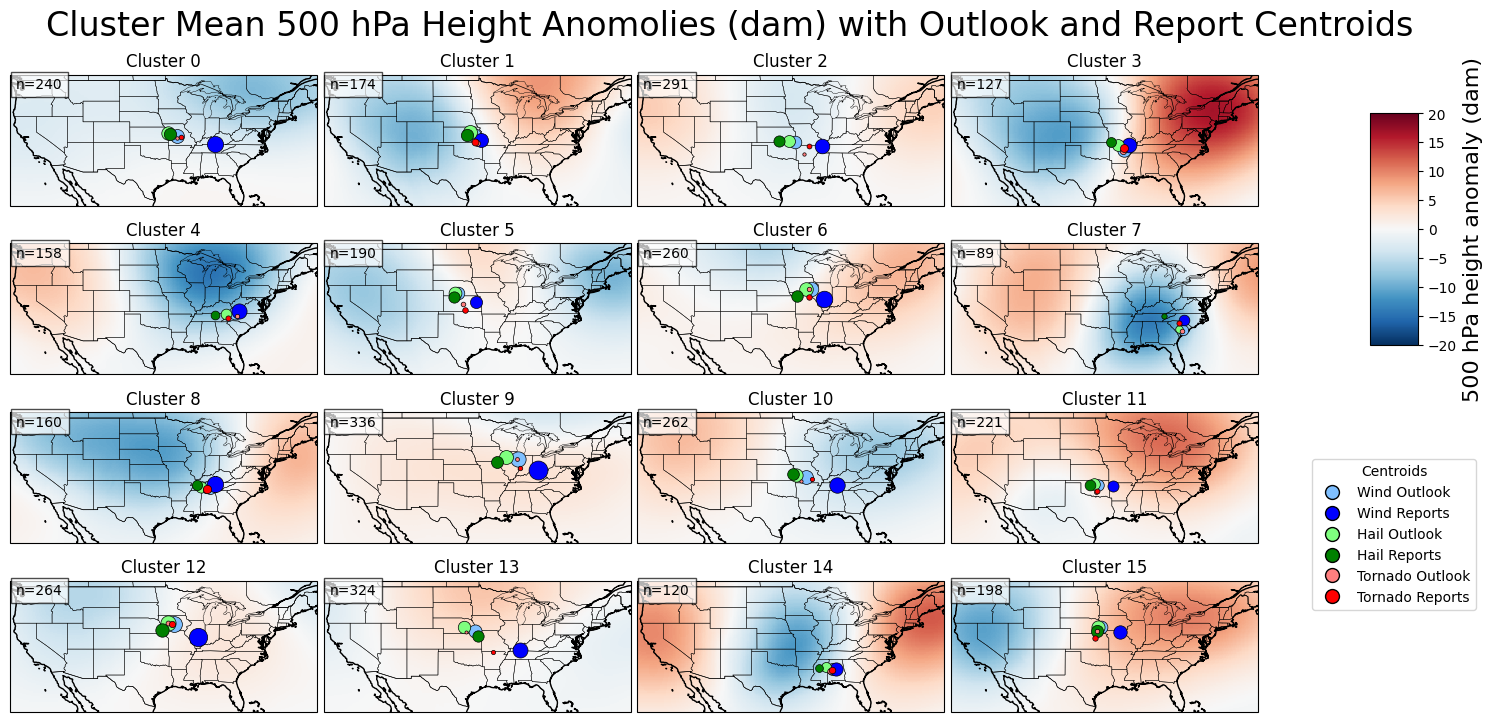

In [338]:
fig = plt.figure(figsize=(16, 8))

# --- main grid for maps (uses constrained layout) ---
gs_maps = fig.add_gridspec(
    nrows=size_1,
    ncols=size_2,
    left=0.05, right=0.83, top=0.92, bottom=0.08,
    wspace=0.02, hspace=0.02
)

axes = []
for r in range(size_1):
    for c in range(size_2):
        ax = fig.add_subplot(gs_maps[r, c], projection=ccrs.PlateCarree())
        axes.append(ax)

# --- side column (independent of map layout) ---
gs_side = fig.add_gridspec(
    nrows=2, ncols=1,
    left=0.90, right=0.93,   # narrower column
    top=0.85, bottom=0.15,
    height_ratios=[1, 1.2]
)

cax = fig.add_subplot(gs_side[0])
lax = fig.add_subplot(gs_side[1])
lax.axis('off')

fig.suptitle(
    'Cluster Mean 500 hPa Height Anomolies (dam) with Outlook and Report Centroids',
    fontsize=24
)


for i, ax in enumerate(axes[:n_clusters]):
    d = cluster_data[i]

    im = ax.pcolormesh(
        d['conus_field']['longitude'],
        d['conus_field']['latitude'],
        d['conus_field'].values,
        cmap='RdBu_r', vmin=-20, vmax=20,
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)

    ax.set_title(f'Cluster {i}')
    ax.text(
        0.02, 0.98, f'n={d["count"]}',
        transform=ax.transAxes, ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.7)
    )

    for (clon, clat, size), color in zip(
        d['centroids'],
        ['#7fbfff','blue','#7fff7f','green','#ff7f7f','red']
    ):
        ax.scatter(
            clon, clat, s=size*5, color=color,
            edgecolor='k', linewidth=0.5,
            transform=ccrs.PlateCarree(), zorder=10
        )

# colorbar lives in its own gridspec column
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('500 hPa height anomaly (dam)', fontsize=16)


# --- legend proxies ---
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#7fbfff', markeredgecolor='k', markersize=10,
           label='Wind Outlook'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='blue', markeredgecolor='k', markersize=10,
           label='Wind Reports'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#7fff7f', markeredgecolor='k', markersize=10,
           label='Hail Outlook'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', markeredgecolor='k', markersize=10,
           label='Hail Reports'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#ff7f7f', markeredgecolor='k', markersize=10,
           label='Tornado Outlook'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markeredgecolor='k', markersize=10,
           label='Tornado Reports'),
]
# legend
lax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,
    title='Centroids'
)

plt.savefig(save_dir + 'composites.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig(save_dir + 'composites.png', dpi = 1000, bbox_inches='tight')
plt.show()

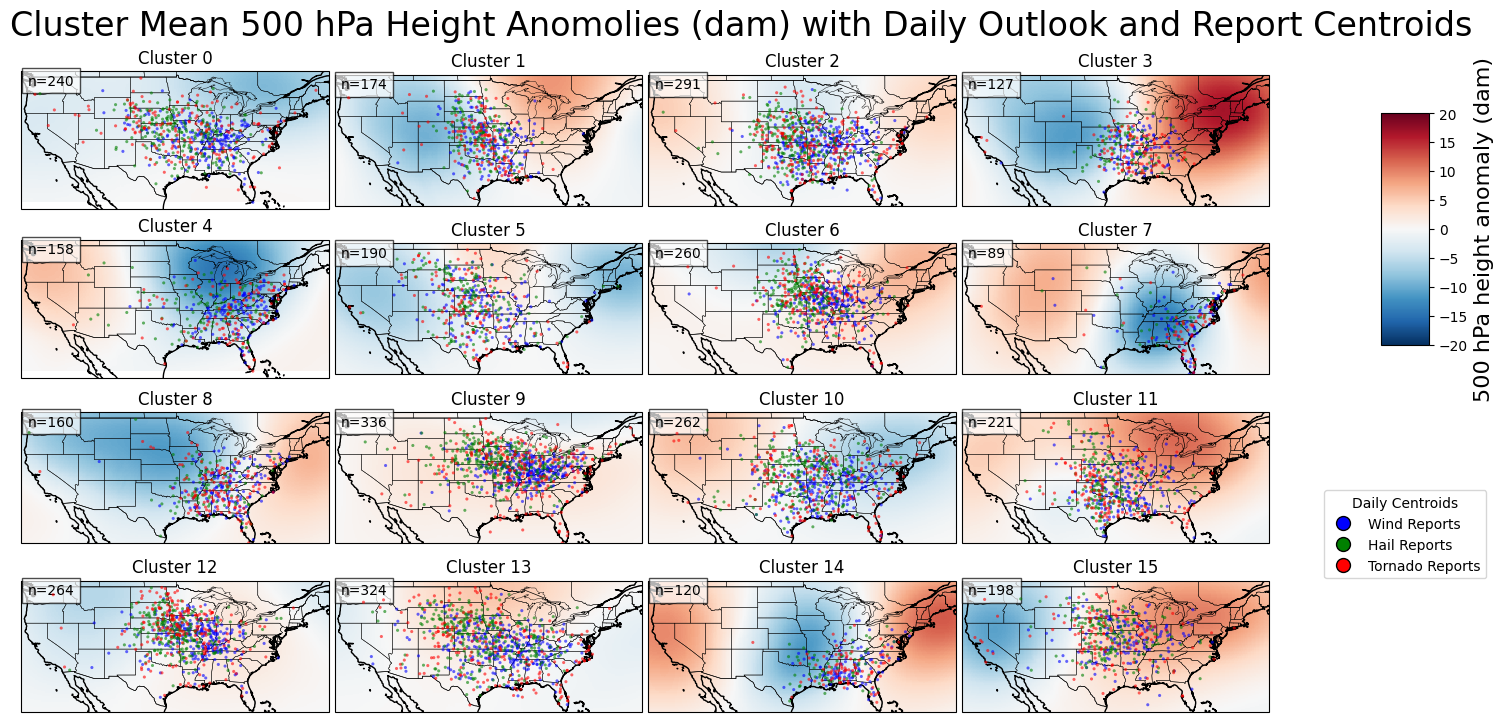

In [339]:
fig = plt.figure(figsize=(16, 8))

# --- main grid for maps (uses constrained layout) ---
gs_maps = fig.add_gridspec(
    nrows=size_1,
    ncols=size_2,
    left=0.05, right=0.83, top=0.92, bottom=0.08,
    wspace=0.02, hspace=0.02
)

axes = []
for r in range(size_1):
    for c in range(size_2):
        ax = fig.add_subplot(gs_maps[r, c], projection=ccrs.PlateCarree())
        axes.append(ax)

# --- side column (independent of map layout) ---
gs_side = fig.add_gridspec(
    nrows=2, ncols=1,
    left=0.90, right=0.93,   # narrower column
    top=0.85, bottom=0.15,
    height_ratios=[1, 1.2]
)

cax = fig.add_subplot(gs_side[0])
lax = fig.add_subplot(gs_side[1])
lax.axis('off')

fig.suptitle(
    'Cluster Mean 500 hPa Height Anomolies (dam) with Daily Outlook and Report Centroids',
    fontsize=24
)


for i, ax in enumerate(axes[:n_clusters]):
    d = cluster_data[i]

    im = ax.pcolormesh(
        d['conus_field']['longitude'],
        d['conus_field']['latitude'],
        d['conus_field'].values,
        cmap='RdBu_r', vmin=-20, vmax=20,
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)

    ax.set_title(f'Cluster {i}')
    ax.text(
        0.02, 0.98, f'n={d["count"]}',
        transform=ax.transAxes, ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.7)
    )

    for pts, color in zip(
    d['day_centroids'],
        ['blue', 'green', 'red']
    ):
        lons, lats = zip(*pts)
        # remove all non-conus points (lat outside 24-50, lon outside -125 to -66)
        lons1 = [lon for lon, lat in zip(lons, lats) if 24 <= lat <= 50 and -125 <= lon <= -66]
        lats1 = [lat for lon, lat in zip(lons, lats) if 24 <= lat <= 50 and -125 <= lon <= -66]
        
        ax.scatter(
            lons1, lats1,
            s=5, alpha=0.6,
            color=color,
            edgecolor='none',
            transform=ccrs.PlateCarree(),
            zorder=10
        )

# colorbar lives in its own gridspec column
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('500 hPa height anomaly (dam)', fontsize=16)


# --- legend proxies ---
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='blue', markeredgecolor='k', markersize=10,
           label='Wind Reports'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', markeredgecolor='k', markersize=10,
           label='Hail Reports'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markeredgecolor='k', markersize=10,
           label='Tornado Reports'),
]
# legend
lax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,
    title='Daily Centroids'
)

plt.savefig(save_dir + 'composites_v2.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig(save_dir + 'composites_v2.png', dpi = 1000, bbox_inches='tight')
plt.show()

In [340]:
Ny = 97
Nx = 97
center = 48  # index of center point

deg = (np.arange(Nx) - center) / 4.0

def plot_storm_field(varname, vmin, vmax, cmap, title, savepath):
    fig = plt.figure(figsize=(9, 8))

    gs_maps = fig.add_gridspec(
        nrows=size_1,
        ncols=size_2,
        left=0.05, right=0.83, top=0.92, bottom=0.08,
        wspace=0.02, hspace=0.02
    )

    axes = []
    for r in range(size_1):
        for c in range(size_2):
            ax = fig.add_subplot(gs_maps[r, c])
            axes.append(ax)

    gs_side = fig.add_gridspec(
        nrows=1, ncols=1,
        left=0.88, right=0.91,
        top=0.85, bottom=0.15,
    )
    cax = fig.add_subplot(gs_side[0])

    fig.suptitle(title, fontsize=24)

    for i, ax in enumerate(axes[:n_clusters]):
        d = cluster_data[i]
        field = d["storm_fields"][varname]

        im = ax.imshow(
            field.values,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            extent=[deg[0], deg[-1], deg[0], deg[-1]],
            aspect="equal",
        )

        ax.set_title(f'Cluster {i}')
        ax.text(
            0.02, 0.98, f'n={d["count"]}',
            transform=ax.transAxes, ha='left', va='top',
            bbox=dict(facecolor='white', alpha=0.7)
        )

        if i % size_2 == 0:
            ax.set_ylabel("Degrees from center")
        if i // size_2 == size_1 - 1:
            ax.set_xlabel("Degrees from center")

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(varname, fontsize=16)

    plt.savefig(savepath + ".pdf", dpi=1000, bbox_inches='tight')
    plt.savefig(savepath + ".png", dpi=1000, bbox_inches='tight')
    plt.show()

def plot_storm_vector_field(
    u_var, v_var,
    vmin, vmax,
    cmap,
    title,
    savepath,
    stride=5,
    scale=2
):
    fig = plt.figure(figsize=(9, 8))

    gs_maps = fig.add_gridspec(
        nrows=size_1,
        ncols=size_2,
        left=0.05, right=0.83, top=0.92, bottom=0.08,
        wspace=0.02, hspace=0.02
    )

    axes = []
    for r in range(size_1):
        for c in range(size_2):
            ax = fig.add_subplot(gs_maps[r, c])
            axes.append(ax)

    gs_side = fig.add_gridspec(
        nrows=1, ncols=1,
        left=0.88, right=0.91,
        top=0.85, bottom=0.15,
    )
    cax = fig.add_subplot(gs_side[0])

    fig.suptitle(title, fontsize=24)

    # grid for quiver
    X, Y = np.meshgrid(deg, deg)

    for i, ax in enumerate(axes[:n_clusters]):
        d = cluster_data[i]

        u = d["storm_fields"][u_var].values
        v = d["storm_fields"][v_var].values

        mag = np.sqrt(u**2 + v**2)

        im = ax.imshow(
            mag,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            extent=[deg[0], deg[-1], deg[0], deg[-1]],
            aspect="equal",
        )

        ax.quiver(
            X[::stride, ::stride],
            Y[::stride, ::stride],
            u[::stride, ::stride],
            v[::stride, ::stride],
            color="black",
            scale=scale,
            width=0.003
        )

        ax.set_title(f'Cluster {i}')
        ax.text(
            0.02, 0.98, f'n={d["count"]}',
            transform=ax.transAxes, ha='left', va='top',
            bbox=dict(facecolor='white', alpha=0.7)
        )
        
        if i % size_2 == 0:
            ax.set_ylabel("Degrees from center")
        if i // size_2 == size_1 - 1:
            ax.set_xlabel("Degrees from center")

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Magnitude", fontsize=16)

    plt.savefig(savepath + ".pdf", dpi=1000, bbox_inches='tight')
    plt.savefig(savepath + ".png", dpi=1000, bbox_inches='tight')
    plt.show()

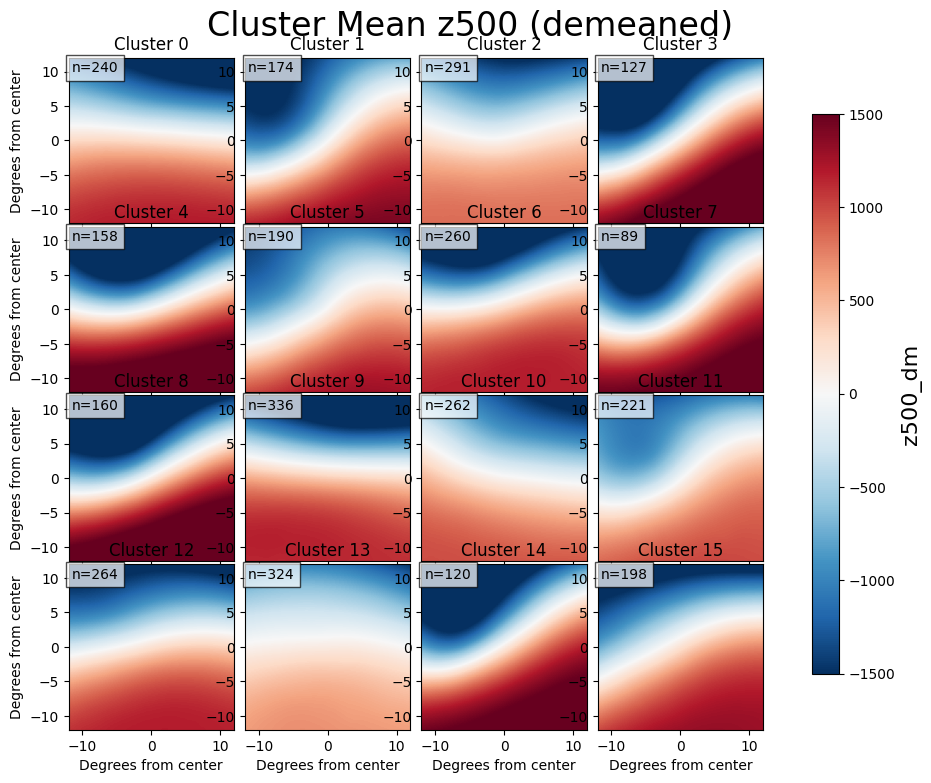

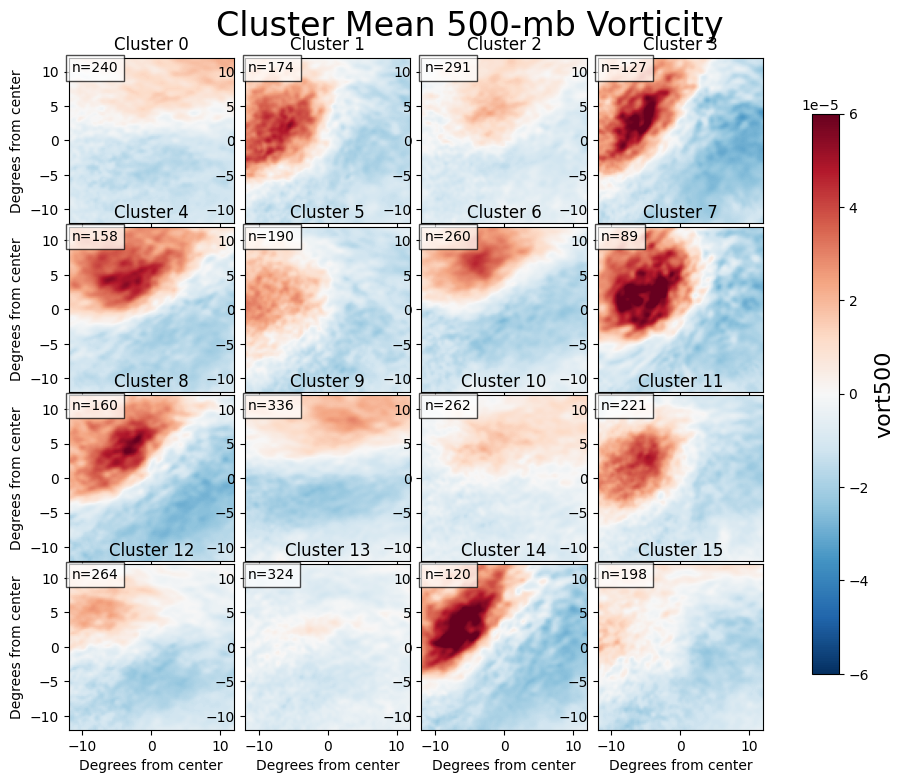

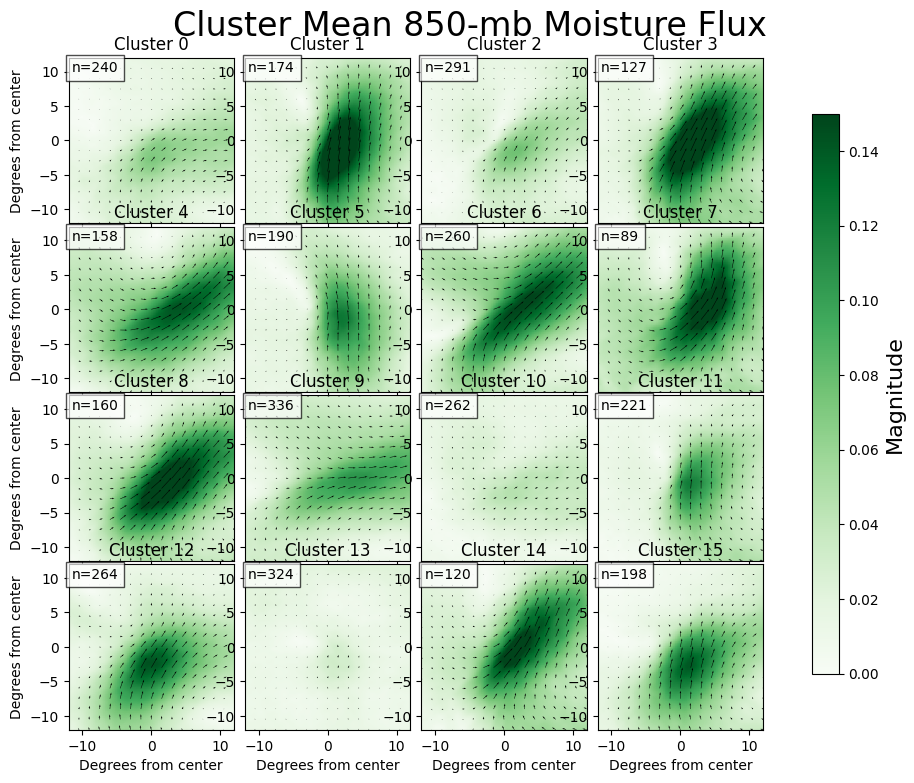

In [341]:
plot_storm_field(
    "z500_dm",
    vmin=-1500, vmax=1500,
    cmap="RdBu_r",
    title="Cluster Mean z500 (demeaned)",
    savepath=save_dir + "z500_dm_composites"
)

plot_storm_field(
    "vort500",
    vmin=-6e-5, vmax=6e-5,
    cmap="RdBu_r",
    title="Cluster Mean 500-mb Vorticity",
    savepath=save_dir + "vort500_composites"
)

#plot_storm_field(
#    "lap_z500",
#    vmin=-1e-8, vmax=1e-8,
#    cmap="RdBu_r",
#    title="Cluster Mean Laplacian of z500",
#    savepath=save_dir + "lap_z500_composites"
#)

plot_storm_vector_field(
    "qflux_u850",
    "qflux_v850",
    vmin=0,
    vmax=0.15,
    cmap="Greens",
    title="Cluster Mean 850-mb Moisture Flux",
    savepath=save_dir + "qflux_vectors_850",
    stride=6
)

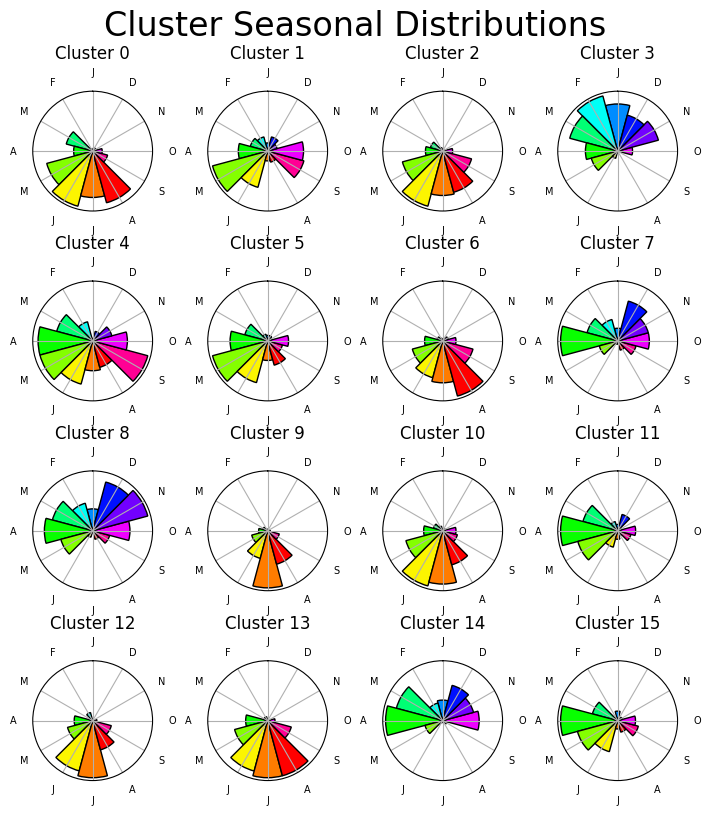

In [342]:
import matplotlib.cm as cm
fig, axes = plt.subplots(
    size_1, size_2,
    subplot_kw={'polar': True},
    figsize=(7, 8),
    constrained_layout=True
)

fig.suptitle('Cluster Seasonal Distributions', fontsize=24)

axes = axes.ravel()
angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
labels = np.array(['J','F','M','A','M','J','J','A','S','O','N','D'])

# Color mapping:
# start hue at September, then proceed backward through the year
start = 7  # September
month_order = (start - np.arange(12)) % 12
colors_by_month = cm.hsv(month_order / 12.0)

for i, ax in enumerate(axes[:n_clusters]):
    counts = cluster_data[i]['rose']

    # Polar orientation: January at top, CCW months
    ax.set_theta_zero_location('N')   # top
    ax.set_theta_direction(1)         # counterclockwise

    ax.bar(
        angles,
        counts,
        width=2*np.pi/12,
        color=colors_by_month,
        edgecolor='k'
    )

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticks([])
    ax.set_title(f'Cluster {i}')

plt.savefig(save_dir + 'seasonal.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig(save_dir + 'seasonal.png', dpi = 1000, bbox_inches='tight')

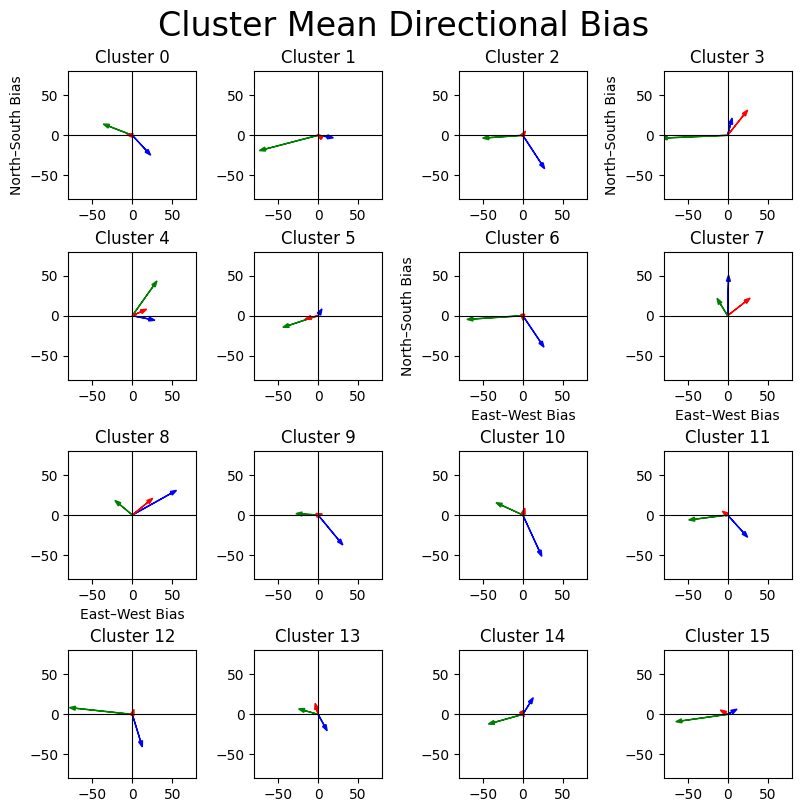

In [343]:
fig, axes = plt.subplots(
    size_1, size_2,
    figsize=(8, 8),
    constrained_layout=True
)
axes = axes.ravel()

fig.suptitle('Cluster Mean Directional Bias', fontsize=24)

scale = 1000

plot_width = 80

for i, ax in enumerate(axes[:n_clusters]):
    ax.set_aspect('equal')
    ax.set_xlim(-plot_width, plot_width)
    ax.set_ylim(-plot_width, plot_width)

    # Centered axes
    ax.axhline(0, color='k', linewidth=0.8)
    ax.axvline(0, color='k', linewidth=0.8)

    for (e_var, n_var), color in zip(
        cluster_data[i]['compass'],
        ['blue', 'green', 'red']
    ):
        e, n = cluster_data[i]['compass'][(e_var, n_var)]
        ax.arrow(
            0, 0,
            e/scale, n/scale,
            color=color,
            width=0.03,
            length_includes_head=True,
            head_width=5
        )
    if i in [0, 3, 6]:
        ax.set_ylabel('North–South Bias')
    if i in [6, 7, 8]:
        ax.set_xlabel('East–West Bias')
    
    ax.set_title(f'Cluster {i}')

plt.savefig(save_dir + 'directional.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig(save_dir + 'directional.png', dpi = 1000, bbox_inches='tight')

In [344]:
# Adapted from https://gist.github.com/djgagne/64516e3ea268ec31fb34

def performance_diagram(pods, fars, obj_labels, colors, markers, filename = '', save = False, show = True, figsize=(9, 8), points = True, xlabel="Success Ratio (1-FAR)",
                        ylabel="Probability of Detection", ticks=np.arange(0, .6, 0.1), dpi=300, csi_cmap="Blues",
                        csi_label="Critical Success Index", title="Performance Diagram",
                        legend_params=dict(loc=4, fontsize=12, framealpha=1, frameon=True),
                        ax = None, show_cbar=False, show_legend=False, show_xlabel = False, show_ylabel = False):
    """
    Draws a performance diagram from a set of POD lists and FAR lists.
    :param pods: list or array of POD arrays.
    :param fars: list or array of FAR arrays.
    :param obj_labels: list or array of labels describing each DistributedROC object.
    :param colors: list of color strings
    :param markers: list of markers.
    :param filename: output filename.
    :param save: whether the figure will be saved
    :param show: whether the figure will be shown in the console
    :param figsize: tuple with size of the figure in inches.
    :param points: True if the plotted points should be separate, otherwise connected
    :param xlabel: Label for the x-axis
    :param ylabel: Label for the y-axis
    :param ticks: Array of ticks used for x and y axes
    :param dpi: DPI of the output image
    :param csi_cmap: Colormap used for the CSI contours
    :param csi_label: Label for the CSI colorbar
    :param ax: Axis object to plot the diagram
    :return:
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        own_fig = True
    else:
        fig = ax.figure  # Get figure from existing axis
        own_fig = False

    grid_ticks = np.arange(0, .51, 0.01)
    sr_g, pod_g = np.meshgrid(grid_ticks, grid_ticks)
    bias = pod_g / sr_g
    csi = 1.0 / (1.0 / sr_g + 1.0 / pod_g - 1.0)

    csi_contour = ax.contourf(sr_g, pod_g, csi, np.arange(.025, .325, 0.025), extend="max", cmap=csi_cmap)
    b_contour = ax.contour(sr_g, pod_g, bias, [.25, 0.5, 1, 2, 4], colors="k", linestyles="dashed")
    ax.clabel(b_contour, fmt="%1.2f", manual=[(0.1, 0.45), (0.2, 0.45), (0.35, 0.35), (.45, .2), (.45, .1)])
    for r, (pod, far) in enumerate(zip(pods, fars)):
        if points:
            ax.scatter(1 - far, pod, color=colors[r], label=obj_labels[r], s = 50)
        else:
            ax.plot(1 - far, pod, marker=markers[r], color=colors[r], label=obj_labels[r], markersize = 5, linewidth = 1)
            shift0 = .03
            shift1 = .03
            if r == 3:
                shift1 = 0
            ax.annotate('2002', xy = (1-far[1], pod[1]), xytext=(1-far[1]-shift1, pod[1]+shift0), arrowprops=dict(arrowstyle="->"))
            ax.annotate('2023', xy = (1-far[-1], pod[-1]), xytext=(1-far[-1]+shift0, pod[-1]-shift1), arrowprops=dict(arrowstyle="->"))
    if show_xlabel:
        ax.set_xlabel(xlabel, fontsize=14)
    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_title(title, fontsize=14)
    ax.text(0.24,0.28,"Frequency Bias",fontdict=dict(fontsize=8, rotation=45))

    if len(obj_labels) > 8:
        legend_params=dict(loc='center left', bbox_to_anchor=(1.3, 0.5), fontsize=12, framealpha=1, frameon=True)
    
    cbar = None
    if show_cbar:
        cbar = fig.colorbar(csi_contour)
        cbar.set_label(csi_label, fontsize=14)

    if show_legend:
        ax.legend(**legend_params)

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    if show and own_fig:
        plt.show()
    return csi_contour

C:\Users\miles\AppData\Local\Temp\ipykernel_5976\2464297428.py:38: RuntimeWarning: divide by zero encountered in divide
  bias = pod_g / sr_g
C:\Users\miles\AppData\Local\Temp\ipykernel_5976\2464297428.py:38: RuntimeWarning: invalid value encountered in divide
  bias = pod_g / sr_g
C:\Users\miles\AppData\Local\Temp\ipykernel_5976\2464297428.py:39: RuntimeWarning: divide by zero encountered in divide
  csi = 1.0 / (1.0 / sr_g + 1.0 / pod_g - 1.0)


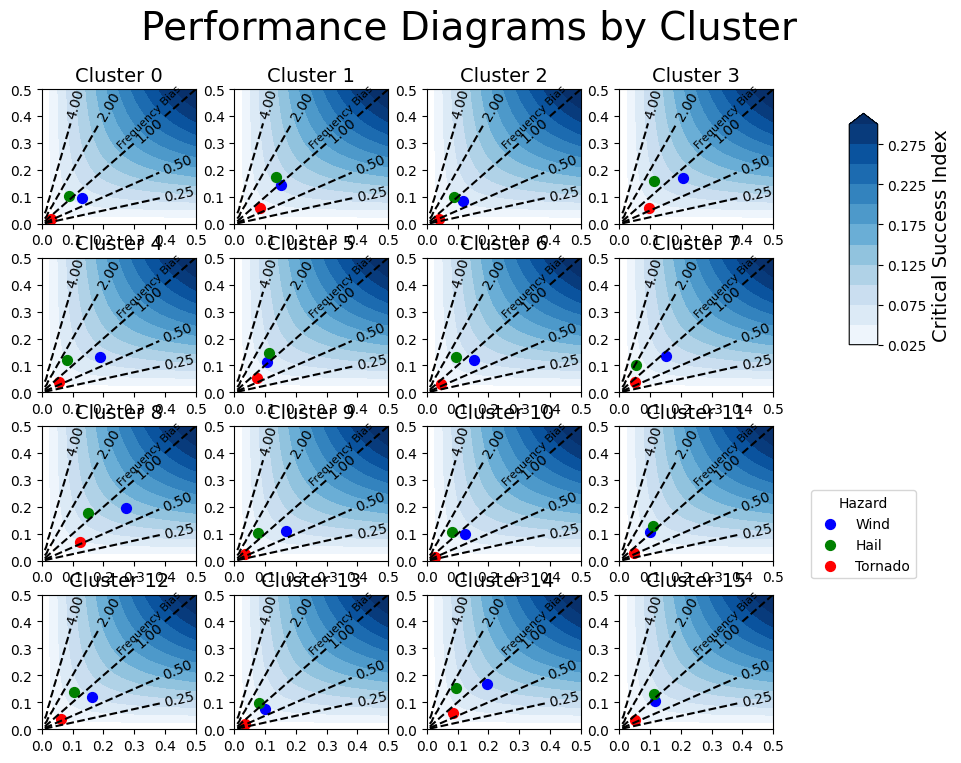

In [345]:
fig = plt.figure(figsize=(9.5, 8))

gs_maps = fig.add_gridspec(
    nrows=size_1,
    ncols=size_2,
    left=0.05, right=0.82,
    top=0.88, bottom=0.08,
    wspace=0.25, hspace=0.25
)

gs_side = fig.add_gridspec(
    nrows=2, ncols=1,
    left=0.90, right=0.93,   # narrower column
    top=0.85, bottom=0.15,
    height_ratios=[1, 1.2]
)

cax = fig.add_subplot(gs_side[0])
lax = fig.add_subplot(gs_side[1])
lax.axis('off')

fig.suptitle('Performance Diagrams by Cluster', fontsize=28)

axes = []
for i in range(size_1 * size_2):
    ax = fig.add_subplot(gs_maps[i // size_2, i % size_2])
    axes.append(ax)

# --- plotting ---
for i in range(n_clusters):
    d = cluster_data[i]

    csi_contour = performance_diagram(
        d['pods'],
        d['fars'],
        d['labels_skill'],
        d['colors'],
        d['markers'],
        ax=axes[i],
        title=f'Cluster {i}',
        show_cbar=False,
        show_legend=False
    )

cbar = fig.colorbar(csi_contour, cax=cax)
cbar.set_label("Critical Success Index", fontsize=14)

handles, labels = axes[0].get_legend_handles_labels()

lax.legend(
    handles,
    labels,
    loc='center',
    frameon=True,
    title='Hazard'
)

plt.savefig(save_dir + 'performance_diagram.pdf', dpi = 1000, bbox_inches='tight')
plt.savefig(save_dir + 'performance_diagram.png', dpi = 1000, bbox_inches='tight')

In [346]:
rows = []
for i in range(n_clusters):
    d = cluster_data[i]
    rows.append([
        i,
        d['avg_cat'],
        d['avg_wind'],
        d['avg_hail'],
        d['avg_tor'],
    ])

table = pd.DataFrame(rows, columns=[
    'Cluster',
    'Avg Category',
    'Avg Max Wind Prob',
    'Avg Max Hail Prob',
    'Avg Max Tornado Prob'
])

table

,Cluster,Avg Category,Avg Max Wind Prob,Avg Max Hail Prob,Avg Max Tornado Prob
0,0,2.095833,0.181458,0.185833,0.031833
1,1,2.597701,0.208621,0.235920,0.068506
2,2,2.130584,0.167010,0.168385,0.030893
3,3,2.535433,0.219685,0.180315,0.069528
4,4,2.234177,0.202532,0.120886,0.041203
5,5,2.321053,0.174474,0.210526,0.051684
6,6,2.300000,0.211731,0.192500,0.041577
7,7,2.224719,0.189326,0.085393,0.052697
8,8,2.587500,0.228125,0.143438,0.071938
9,9,2.199405,0.209673,0.176786,0.031548


In [347]:
# look at model perfromance for each cluster

model_spec = 'cnn3d_gelu_0_5/level=slgt_small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'
results = xr.open_dataset(f'results/predictions_losses/{model_spec}/predictions.nc')
results['cluster'] = (('time'), labels_cluster)

In [348]:
# for each cluster, calculate NLL, baseline NLL, llr, KL(?). Good product could be 9x9 heatmap for each of these

from scipy.stats import chi2

# variables to aggregate
base = results[['nll_pred', 'nll_baseline', 'llr_vals', 'kl_vals', 'mu', 'sigma', 'gamma', 'tau']]

# mean metrics per cluster/target
cluster_means = (
    base
    .groupby(results.cluster)
    .mean(dim='time')
    .rename({'cluster': 'cluster_id'})
)

# number of days in each cluster
Nc = results['cluster'].groupby(results.cluster).count()
Nc = Nc.rename({'cluster': 'cluster_id'})  # (cluster_id,)

# broadcast Nc to (cluster_id, target)
Nc2d = Nc.expand_dims(target=cluster_means.target)

# Λ = 2 * N_c * LLR
Lambda = 2.0 * Nc2d * cluster_means['llr_vals']
Lambda.name = 'lambda_stat'

# optional: chi-square p-value (using k=4 as discussed)
k = 4
pval = xr.apply_ufunc(lambda x: chi2.sf(x, k), Lambda)
pval.name = 'p_value'

# add to dataset
cluster_means = xr.merge([cluster_means, Lambda, pval])

lr_values = (np.exp(cluster_means['llr_vals']) - 1)
lr_values.name = 'likelihood_improvement'

cluster_means = xr.merge([cluster_means, lr_values])

C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


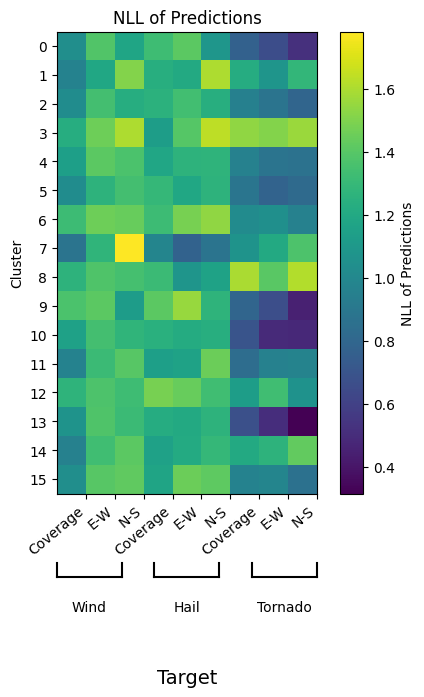

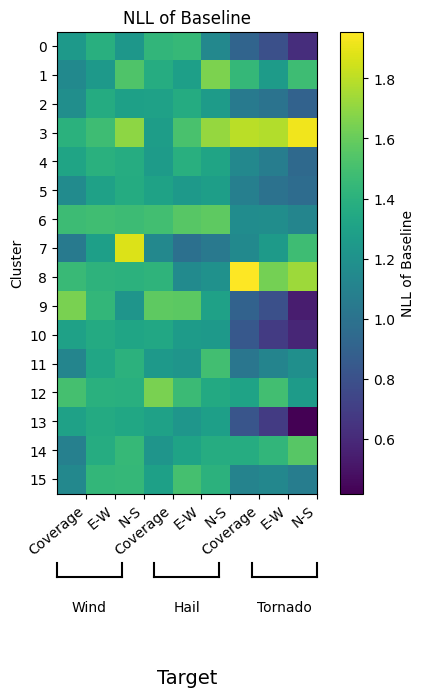

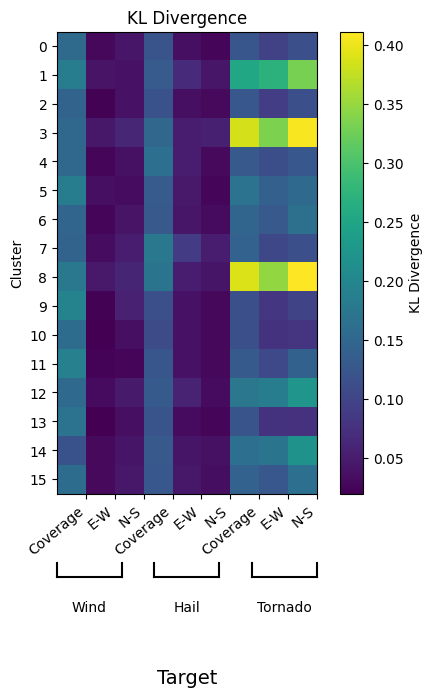

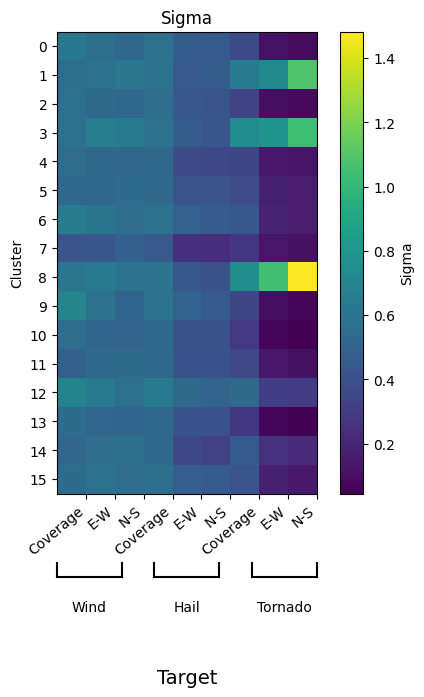

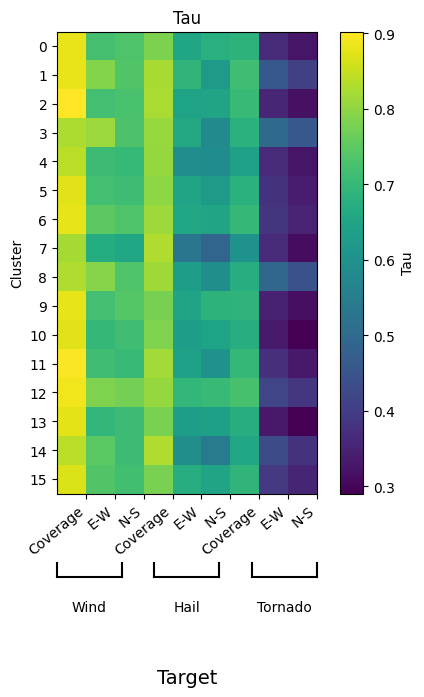

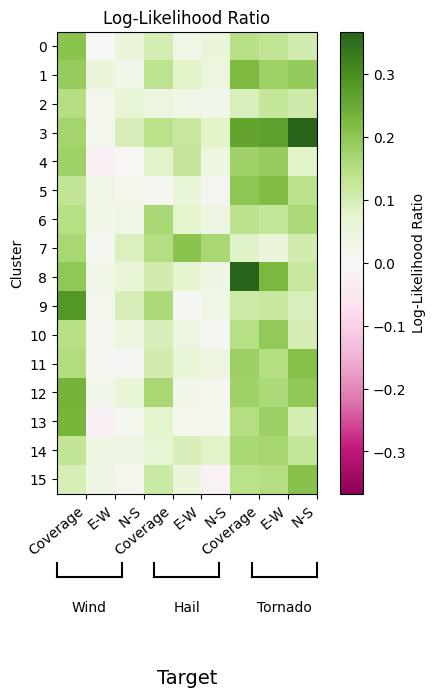

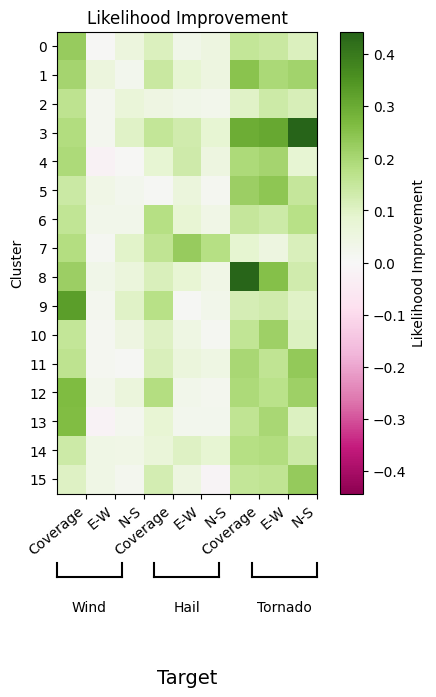

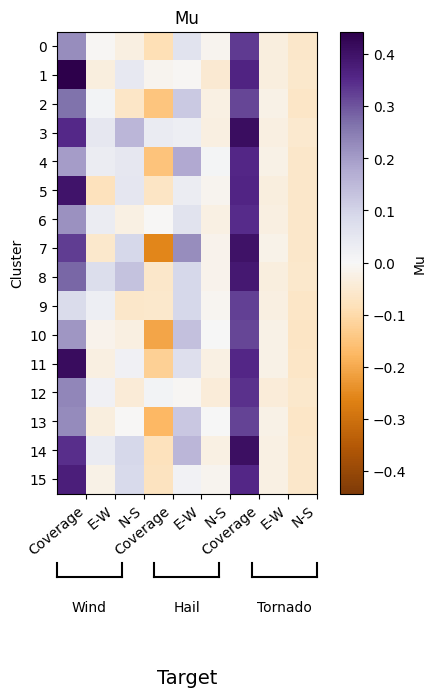

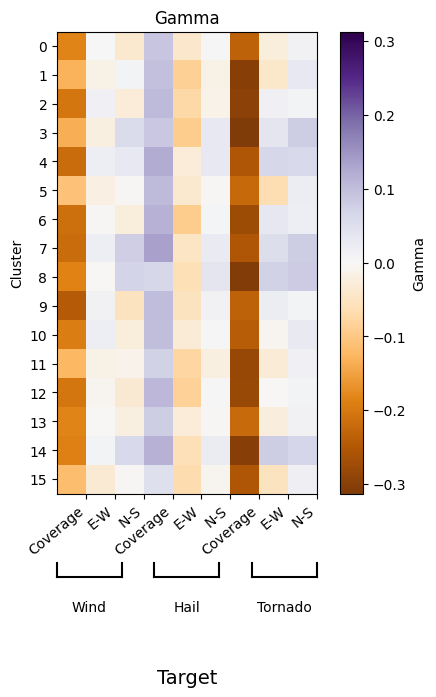

In [350]:
vars_seq = ['nll_pred', 'nll_baseline', 'kl_vals', 'sigma', 'tau']  # sequential
var_div = ['llr_vals', 'likelihood_improvement', 'mu', 'gamma']                       # diverging

name_dict = {
     'nll_pred': 'NLL of Predictions',
     'nll_baseline': 'NLL of Baseline',
     'kl_vals': 'KL Divergence',
     'sigma': 'Sigma',
     'tau': 'Tau',
     'llr_vals': 'Log-Likelihood Ratio',
     'likelihood_improvement': 'Likelihood Improvement',
     'mu': 'Mu',
     'gamma': 'Gamma',
}


def format_target_axis(ax):
    # --- inner labels ---
    inner = ['Coverage', 'E-W', 'N-S'] * 3
    ax.set_xticks(np.arange(0.5, 9.5, 1))
    ax.set_xticklabels(['Coverage', 'E-W', 'N-S'] * 3, rotation=40, ha='right')

    # --- remove any secondary axis artifacts ---
    # (important: avoids duplicate hazard labels)
    for child in ax.get_children():
        if isinstance(child, plt.SecondaryAxis if hasattr(plt, "SecondaryAxis") else type(None)):
            pass

    # --- main xlabel (only place "Target" appears) ---
    ax.set_xlabel('Target', fontsize=14, labelpad=80)

    # --- bracket groups (manual, black only) ---
    y = -0.18
    groups = [(0, 2), (3, 5), (6, 8)]
    labels = ['Wind', 'Hail', 'Tornado']

    for (x0, x1), lab in zip(groups, labels):
        x0f, x1f = x0 / 8, x1 / 8

        ax.plot([x0f, x1f], [y, y],
                transform=ax.transAxes, clip_on=False,
                color='black')

        ax.plot([x0f, x0f], [y, y + 0.03],
                transform=ax.transAxes, clip_on=False,
                color='black')

        ax.plot([x1f, x1f], [y, y + 0.03],
                transform=ax.transAxes, clip_on=False,
                color='black')

        ax.text((x0f + x1f) / 2, y - 0.05, lab,
                transform=ax.transAxes,
                ha='center', va='top', color='black')
        

# --- sequential colormap plots ---
for v in vars_seq:
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cluster_means[v], aspect='equal')
    fig.colorbar(im, ax=ax, label=name_dict[v])

    ax.set_xlabel('Target')
    ax.set_ylabel('Cluster')
    ax.set_yticks(range(size_1 * size_2))
    ax.set_title(name_dict[v])

    format_target_axis(ax)
    plt.savefig(f'{save_dir}heatmaps/{v}.pdf', dpi = 1000, bbox_inches='tight')
    plt.savefig(f'{save_dir}heatmaps/{v}.png', dpi = 1000, bbox_inches='tight')
    plt.show()

for v in var_div:
        # --- diverging for llr ---
        llr = cluster_means[v]
        vmax = abs(llr).max().item()

        fig, ax = plt.subplots(figsize=(6, 6))
        if v in ['llr_vals', 'likelihood_improvement']:
             cmap = 'PiYG'
        else:
             cmap = 'PuOr'
        im = ax.imshow(llr, aspect='equal', vmin=-vmax, vmax=vmax, cmap=cmap)
        fig.colorbar(im, ax=ax, label=name_dict[v])

        ax.set_xlabel('Target')
        ax.set_ylabel('Cluster')
        ax.set_yticks(range(size_1 * size_2))
        ax.set_title(name_dict[v])

        format_target_axis(ax)
        plt.savefig(f'{save_dir}heatmaps/{v}.pdf', dpi = 1000, bbox_inches='tight')
        plt.savefig(f'{save_dir}heatmaps/{v}.png', dpi = 1000, bbox_inches='tight')
        plt.show()